# 🔍 EDA Master Cheatsheet
### Manual + Automated Exploratory Data Analysis — All in One Notebook

> **How to use:** Run Section 0 (Setup) once. Then work through sections in order
> for a complete EDA, or jump to any tool directly. Every cell uses the
> **built-in Titanic dataset** — no CSV files needed.

---

## 📚 Table of Contents

| # | Section | What you learn |
|---|---------|---------------|
| 0 | [Setup & Data Loading](#0) | Imports, loading data from seaborn/CSV/Excel |
| 1 | [First Look](#1) | shape, head, dtypes, info, describe |
| 2 | [Missing Values](#2) | isnull, heatmaps, imputation strategies |
| 3 | [Univariate Analysis](#3) | distributions for numerical & categorical columns |
| 4 | [Bivariate Analysis](#4) | relationships between two variables |
| 5 | [Multivariate Analysis](#5) | correlations, pair plots, grouped analysis |
| 6 | [Outlier Detection](#6) | IQR method, z-score, box plots |
| 7 | [Feature Engineering Hints](#7) | new columns, binning, encoding preview |
| 8 | [EDA Summary Checklist](#8) | what to document before modelling |
| — | [Automated EDA Tools](#auto) | ydata-profiling, sweetviz, dtale, pygwalker, skimpy, dataprep |


---
## 0 · Setup & Data Loading <a id='0'></a>

### Install libraries (run once)
```bash
pip install pandas numpy matplotlib seaborn scipy
# Automated EDA tools (optional — each section below has its own install cmd)
pip install ydata-profiling sweetviz dtale pygwalker skimpy dataprep
```


In [2]:
# ── Core imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Global plot style ────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

print("✅ Libraries loaded")


✅ Libraries loaded


### 0.1 — Loading data

Three common ways to get your data into a DataFrame:

In [3]:
# ── Option A: Built-in seaborn dataset (no file needed) ──────────────────
df = sns.load_dataset('titanic')

# ── Option B: From a CSV file ──────────────────────────────────────────────
# df = pd.read_csv('your_file.csv')

# ── Option C: From an Excel file ──────────────────────────────────────────
# df = pd.read_excel('your_file.xlsx', sheet_name='Sheet1')

# ── Option D: From a URL ──────────────────────────────────────────────────
# df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")


Dataset loaded: 891 rows × 15 columns


In [4]:
# ── Saving your cleaned DataFrame ─────────────────────────────────────────
# df.to_csv('cleaned_data.csv', index=False)      # save as CSV
# df.to_excel('cleaned_data.xlsx', index=False)   # save as Excel
# df.to_parquet('cleaned_data.parquet')           # save as Parquet (fast, compressed)

print("Tip: save to CSV/Excel after cleaning for sharing; Parquet for large files.")


Tip: save to CSV/Excel after cleaning for sharing; Parquet for large files.


---
## 1 · First Look at the Data <a id='1'></a>

Always start here. The goal is to understand:
- **Shape**: how many rows and columns?
- **Column names and types**: what data types do we have?
- **Sample rows**: do the values look sensible?
- **Basic statistics**: ranges, means, counts


In [5]:
# ── Shape ─────────────────────────────────────────────────────────────────
print("Shape:", df.shape)
print(f"  → {df.shape[0]:,} rows, {df.shape[1]} columns")


Shape: (891, 15)
  → 891 rows, 15 columns


In [6]:
# ── First 5 rows ──────────────────────────────────────────────────────────
df.head()           # change to df.tail() for last 5, or df.sample(5) for random 5


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
# ── Column names & data types ─────────────────────────────────────────────
print("Columns and dtypes:")
print(df.dtypes)


Columns and dtypes:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [8]:
# ── Concise summary (non-null counts + dtype) ─────────────────────────────
# This is the fastest way to spot missing data at a glance
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
# ── Descriptive statistics for numerical columns ──────────────────────────
# count, mean, std, min, 25%, 50%, 75%, max
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
# ── Descriptive statistics for categorical columns ────────────────────────
# count, unique values, top value, frequency of top value
df.describe(include='object')


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [11]:
# ── Complete overview: dtype + null count + unique count ──────────────────
overview = pd.DataFrame({
    'dtype'       : df.dtypes,
    'non_null'    : df.notna().sum(),
    'null_count'  : df.isna().sum(),
    'null_%'      : (df.isna().mean() * 100).round(2),
    'unique'      : df.nunique(),
    'sample_value': df.iloc[0]
})
overview


,dtype,non_null,null_count,null_%,unique,sample_value
survived,int64,891,0,0.00,2,0
pclass,int64,891,0,0.00,3,3
sex,object,891,0,0.00,2,male
age,float64,714,177,19.87,88,22.0
sibsp,int64,891,0,0.00,7,1
parch,int64,891,0,0.00,7,0
fare,float64,891,0,0.00,248,7.25
embarked,object,889,2,0.22,3,S
class,category,891,0,0.00,3,Third
who,object,891,0,0.00,3,man


---
## 2 · Missing Values <a id='2'></a>

Missing data is one of the most important things to handle before modelling.

**Decision tree:**
- < 5% missing → safe to drop rows or fill with median/mode
- 5–30% missing → fill with median/mode/model, or create a `_missing` flag column
- > 30% missing → consider dropping the column, or use advanced imputation


In [12]:
# ── Count and percentage of missing values per column ────────────────────
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_%'    : (df.isna().mean() * 100).round(2)
}).sort_values('missing_%', ascending=False)

# Show only columns that actually have missing values
missing[missing['missing_count'] > 0]


,missing_count,missing_%
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


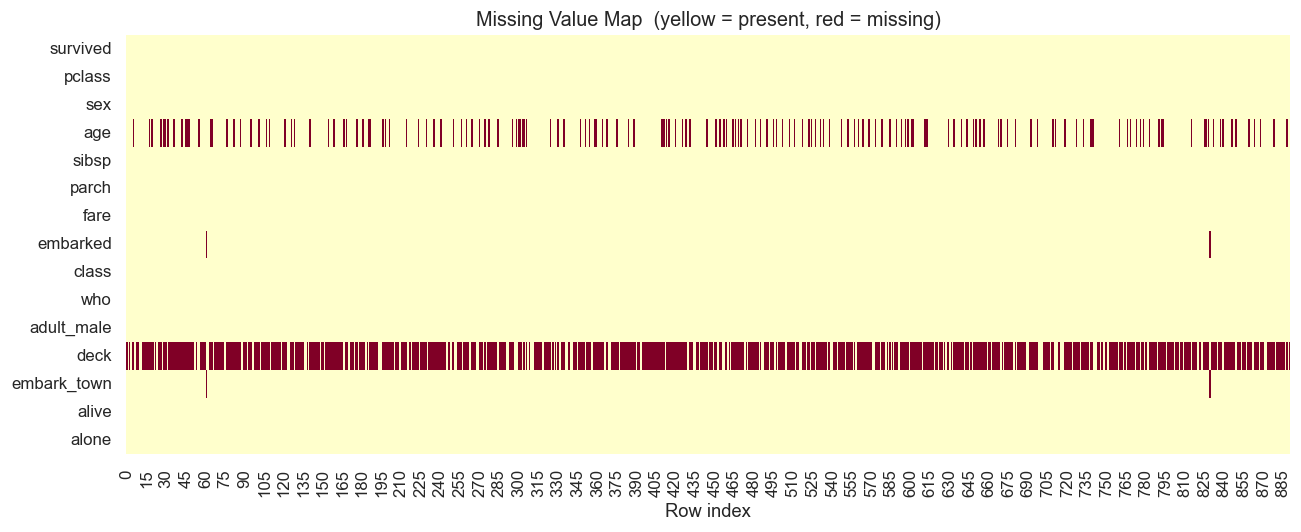

In [13]:
# ── Visual heatmap of missing values ─────────────────────────────────────
# White = present, coloured = missing
fig, ax = plt.subplots(figsize=(12, 5))

# Build a boolean matrix: True where data is missing
missing_matrix = df.isnull().astype(int)

sns.heatmap(
    missing_matrix.T,          # transpose so columns become rows
    cbar=False,                # no colour bar needed (binary)
    cmap='YlOrRd',             # yellow=present, red=missing
    yticklabels=df.columns,
    ax=ax
)
ax.set_title('Missing Value Map  (yellow = present, red = missing)', fontsize=13)
ax.set_xlabel('Row index')
plt.tight_layout()
plt.show()
# ► Tip: install missingno for a richer missing-value visualizer (pip install missingno)


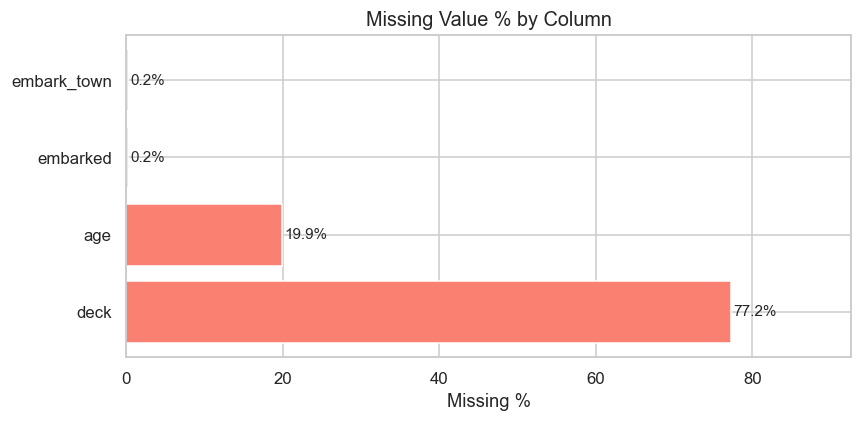

In [14]:
# ── Bar chart of missing value percentages ───────────────────────────────
cols_with_missing = df.columns[df.isna().any()].tolist()
missing_pct       = (df[cols_with_missing].isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_pct.index, missing_pct.values, color='salmon', edgecolor='white')

# Add percentage labels
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10)

ax.set_title('Missing Value % by Column', fontsize=13)
ax.set_xlabel('Missing %')
ax.set_xlim(0, max(missing_pct.values) * 1.2)
plt.tight_layout()
plt.show()


In [15]:
# ── Strategies to handle missing values ──────────────────────────────────
df_clean = df.copy()   # always work on a copy!

# 1. Drop rows where a key column is null
# df_clean = df_clean.dropna(subset=['age'])

# 2. Fill numerical column with median (robust to outliers)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# 3. Fill categorical column with mode (most frequent value)
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

# 4. Drop columns with > 50% missing
threshold = 0.5
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.isna().mean() > threshold])

# 5. Create a binary flag BEFORE filling (preserves info that value was missing)
# df_clean['age_was_missing'] = df['age'].isna().astype(int)

print("Missing values remaining after cleaning:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print("\nAll columns now clean:", df_clean.isna().sum().sum() == 0)


Missing values remaining after cleaning:
embark_town    2
dtype: int64

All columns now clean: False


---
## 3 · Univariate Analysis <a id='3'></a>

Look at **one variable at a time**. Goal: understand its distribution, range,
and any anomalies.


### 3.1 — Numerical columns

In [16]:
# ── Identify numerical vs categorical columns ─────────────────────────────
num_cols = df_clean.select_dtypes(include=['number']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical columns :", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical columns: ['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


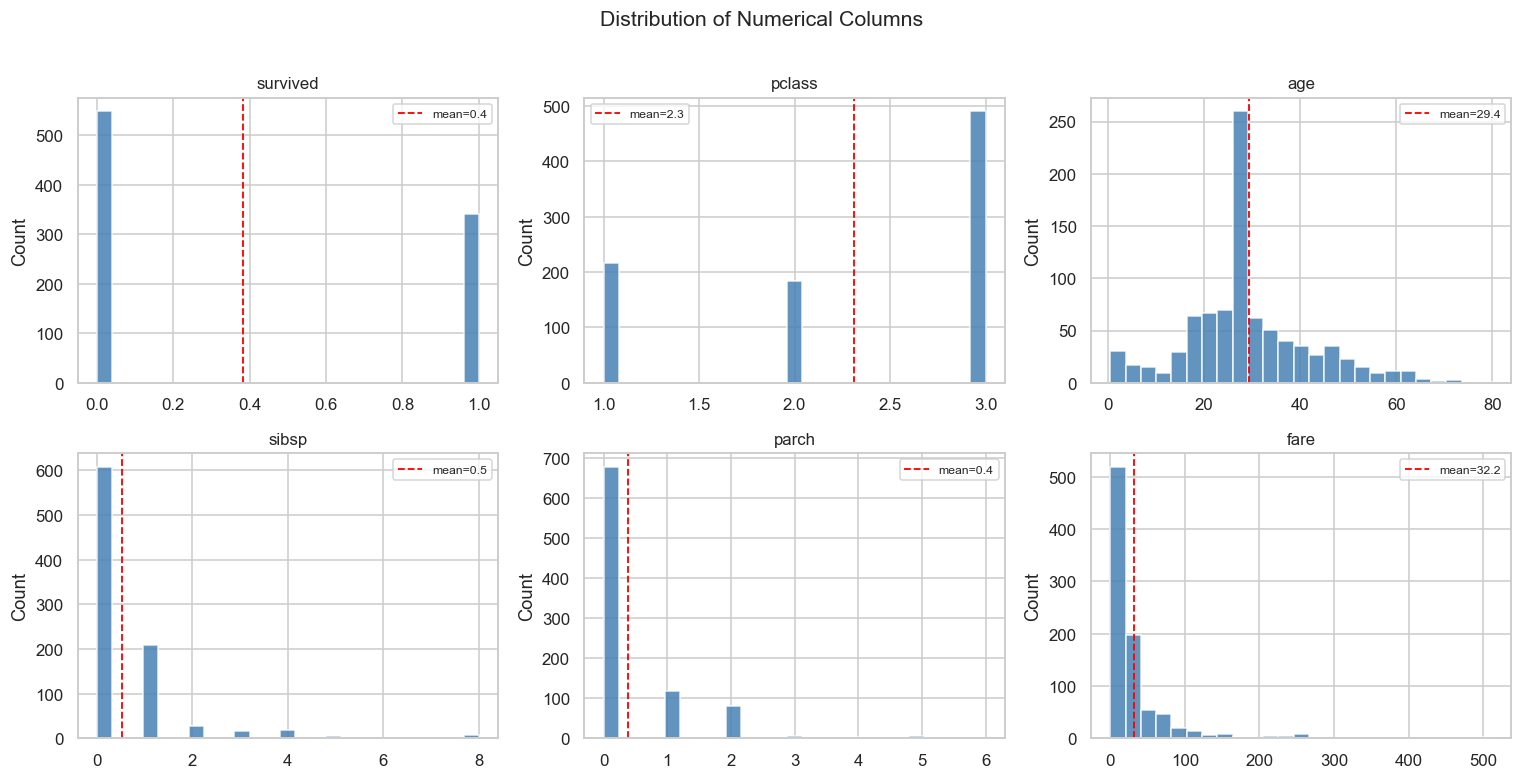

In [17]:
# ── Histograms for all numerical columns (auto-grid) ─────────────────────
n_cols = 3
n_rows = -(-len(num_cols) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col].dropna(), bins=25, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    # Add mean line
    axes[i].axvline(df_clean[col].mean(), color='red', linestyle='--',
                    linewidth=1.2, label=f"mean={df_clean[col].mean():.1f}")
    axes[i].legend(fontsize=8)

# Hide any unused panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Numerical Columns', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
# ► Tip: change bins= to control granularity; add kde=True in sns.histplot() for a curve


In [18]:
# ── Detailed stats for a single numerical column ─────────────────────────
col = 'age'   # ← change this to any numerical column

data = df_clean[col].dropna()

print(f"── Statistics for '{col}' ──────────────────────")
print(f"  Count   : {data.count():,}")
print(f"  Mean    : {data.mean():.2f}")
print(f"  Median  : {data.median():.2f}")
print(f"  Std Dev : {data.std():.2f}")
print(f"  Min     : {data.min():.2f}")
print(f"  Max     : {data.max():.2f}")
print(f"  Q1 (25%): {data.quantile(0.25):.2f}")
print(f"  Q3 (75%): {data.quantile(0.75):.2f}")
print(f"  IQR     : {data.quantile(0.75) - data.quantile(0.25):.2f}")
print(f"  Skewness: {data.skew():.3f}  (0=symmetric, >0=right tail, <0=left tail)")
print(f"  Kurtosis: {data.kurtosis():.3f}  (0=normal, >0=heavy tails)")


── Statistics for 'age' ──────────────────────
  Count   : 891
  Mean    : 29.36
  Median  : 28.00
  Std Dev : 13.02
  Min     : 0.42
  Max     : 80.00
  Q1 (25%): 22.00
  Q3 (75%): 35.00
  IQR     : 13.00
  Skewness: 0.510  (0=symmetric, >0=right tail, <0=left tail)
  Kurtosis: 0.994  (0=normal, >0=heavy tails)


### 3.2 — Categorical columns

In [19]:
# ── Value counts for all categorical columns ─────────────────────────────
for col in cat_cols[:6]:   # limit to first 6 columns
    print(f"\n── {col} ──────────────────────────────")
    print(df_clean[col].value_counts(dropna=False).to_string())



── sex ──────────────────────────────
sex
male      577
female    314

── embarked ──────────────────────────────
embarked
S    646
C    168
Q     77

── class ──────────────────────────────
class
Third     491
First     216
Second    184

── who ──────────────────────────────
who
man      537
woman    271
child     83

── adult_male ──────────────────────────────
adult_male
True     537
False    354

── embark_town ──────────────────────────────
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2


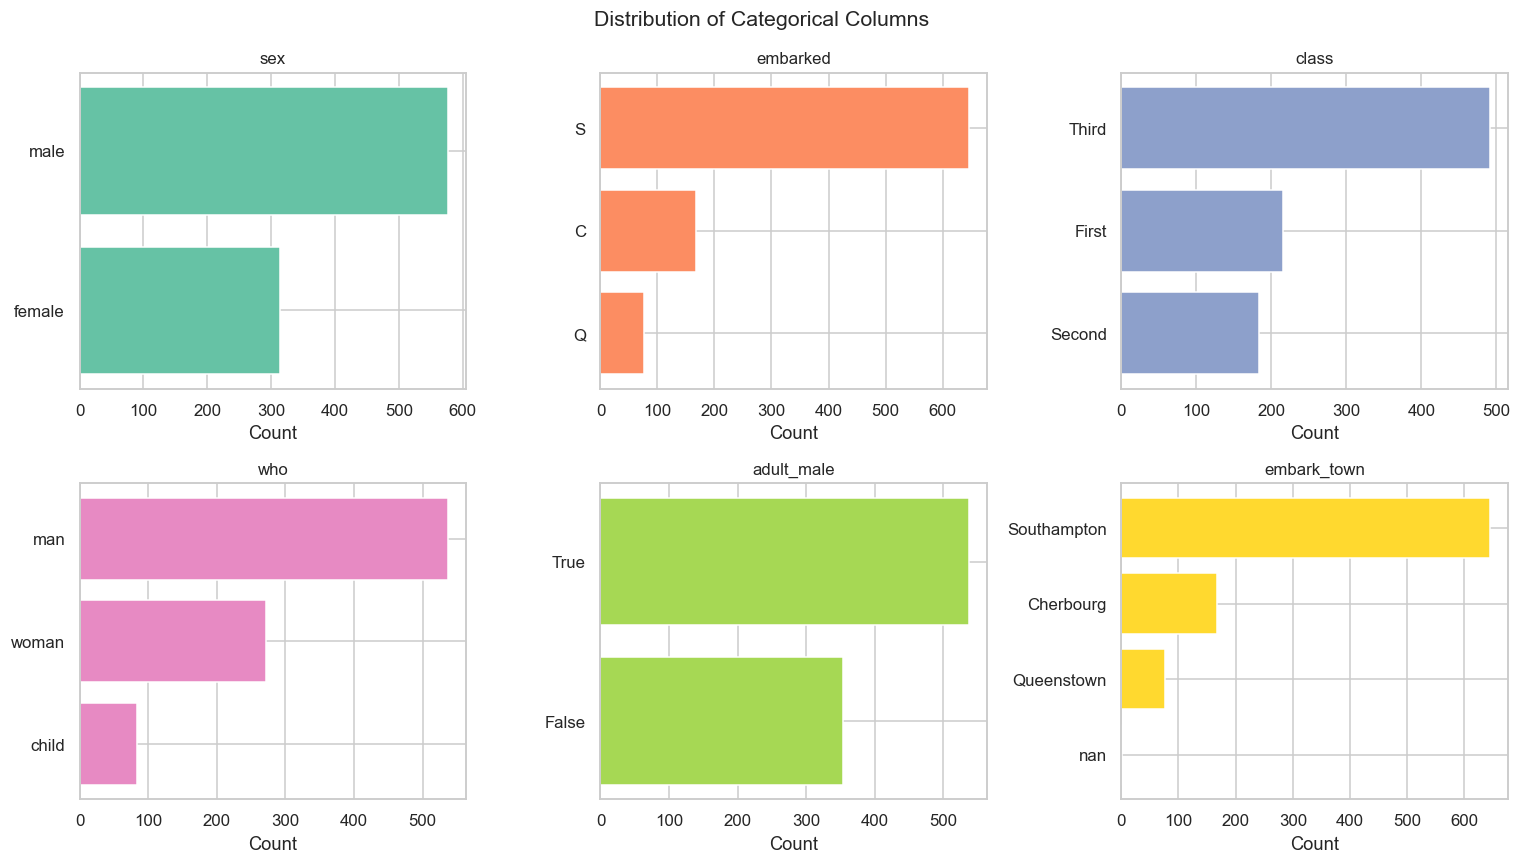

In [20]:
# ── Bar charts for all categorical columns (auto-grid) ───────────────────
n_show = min(len(cat_cols), 6)   # show up to 6 categorical columns
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:n_show]):
    vc = df_clean[col].value_counts(dropna=False).head(10)  # top 10 values
    axes[i].barh(vc.index.astype(str), vc.values,
                 color=sns.color_palette('Set2')[i % 8], edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Count')
    axes[i].invert_yaxis()   # largest bar at top

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Categorical Columns', fontsize=14)
plt.tight_layout()
plt.show()


---
## 4 · Bivariate Analysis <a id='4'></a>

Explore the **relationship between two variables**.

| Variable types | Best chart |
|---------------|-----------|
| Numerical × Numerical | Scatter plot, line plot |
| Categorical × Numerical | Box plot, violin plot, bar plot |
| Categorical × Categorical | Grouped bar, cross-tab, heatmap |


### 4.1 — Numerical × Numerical

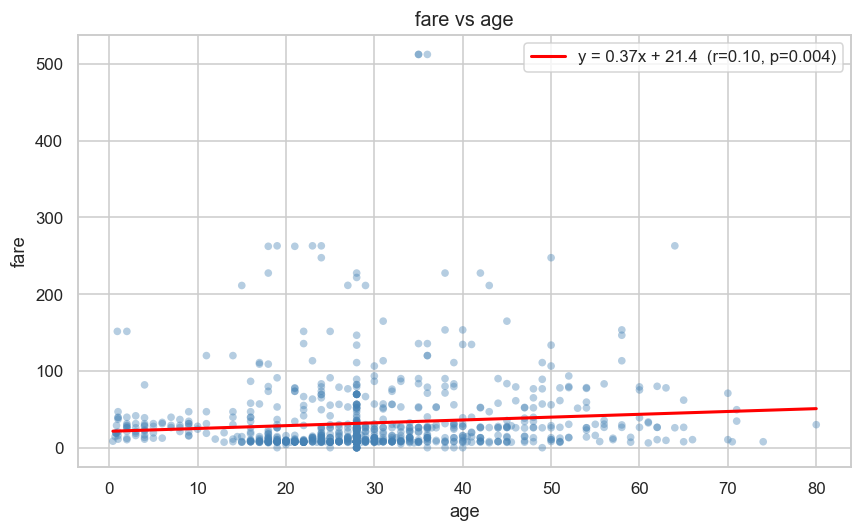

In [21]:
# ── Scatter plot with regression line ────────────────────────────────────
x_col = 'age'
y_col = 'fare'

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_clean[x_col], df_clean[y_col],
           alpha=0.4, s=25, color='steelblue', edgecolors='none')

# Add a linear regression line
mask = df_clean[[x_col, y_col]].notna().all(axis=1)
m, b, r, p, _ = stats.linregress(df_clean.loc[mask, x_col],
                                  df_clean.loc[mask, y_col])
xline = np.linspace(df_clean[x_col].min(), df_clean[x_col].max(), 100)
ax.plot(xline, m * xline + b, color='red', linewidth=2,
        label=f'y = {m:.2f}x + {b:.1f}  (r={r:.2f}, p={p:.3f})')

ax.set_title(f'{y_col} vs {x_col}', fontsize=13)
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.legend()
plt.tight_layout()
plt.show()
# ► Tip: r close to ±1 = strong linear relationship; p < 0.05 = statistically significant


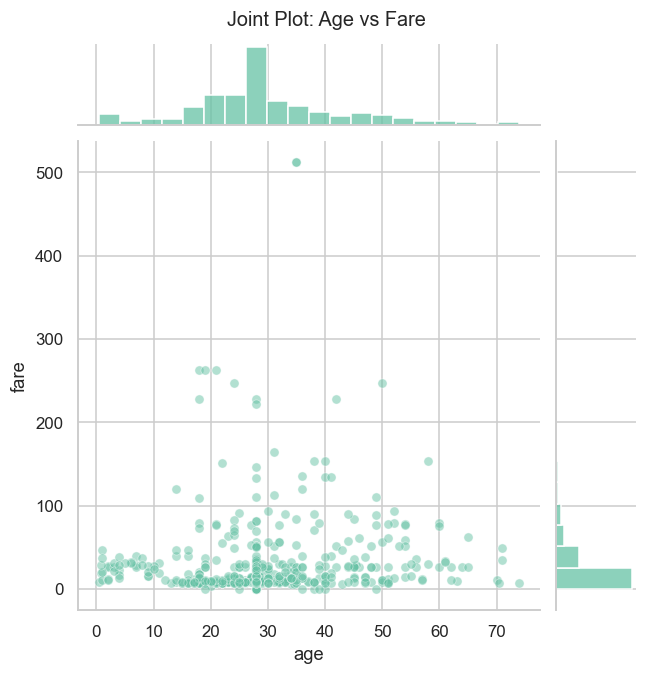

In [22]:
# ── Joint plot (scatter + marginal histograms) ────────────────────────────
# Works best with a cleaned, numeric-only sample
sample = df_clean[['age', 'fare']].dropna().sample(min(500, len(df_clean)), random_state=0)

g = sns.jointplot(data=sample, x='age', y='fare',
                  kind='scatter',      # 'scatter' | 'kde' | 'hex' | 'reg'
                  alpha=0.5, height=6,
                  marginal_kws={'bins': 20})
g.fig.suptitle('Joint Plot: Age vs Fare', y=1.02, fontsize=13)
plt.show()
# ► Tip: kind='kde' gives a smooth density estimate instead of raw scatter points


### 4.2 — Categorical × Numerical

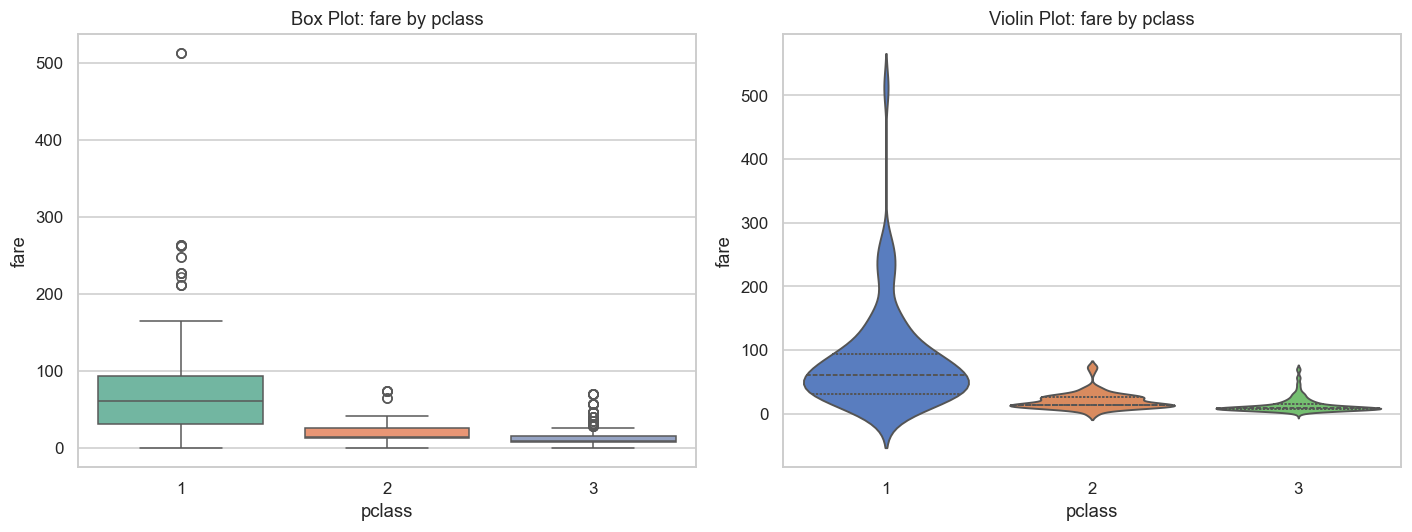

In [23]:
# ── Box plot: numerical variable split by a category ─────────────────────
cat_col = 'pclass'
num_col = 'fare'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Box plot
sns.boxplot(data=df_clean, x=cat_col, y=num_col,
            palette='Set2', ax=axes[0])
axes[0].set_title(f'Box Plot: {num_col} by {cat_col}')

# Right: Violin plot (shows full distribution shape)
sns.violinplot(data=df_clean, x=cat_col, y=num_col,
               palette='muted', inner='quartile', ax=axes[1])
axes[1].set_title(f'Violin Plot: {num_col} by {cat_col}')

plt.tight_layout()
plt.show()


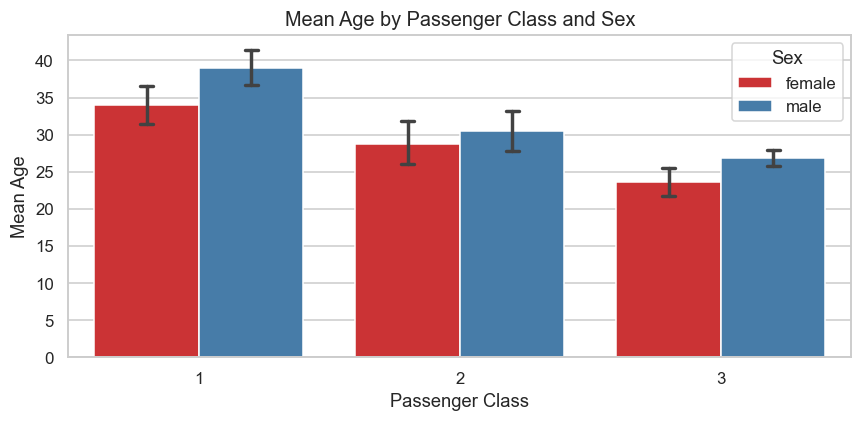

In [24]:
# ── Bar plot with mean + confidence interval ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(data=df_clean, x='pclass', y='age',
            hue='sex',
            palette='Set1',
            errorbar='ci',          # 95% CI error bars
            capsize=0.1,
            ax=ax)

ax.set_title('Mean Age by Passenger Class and Sex', fontsize=13)
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Mean Age')
ax.legend(title='Sex')
plt.tight_layout()
plt.show()
# ► Tip: errorbar='sd' shows ± 1 standard deviation instead of CI


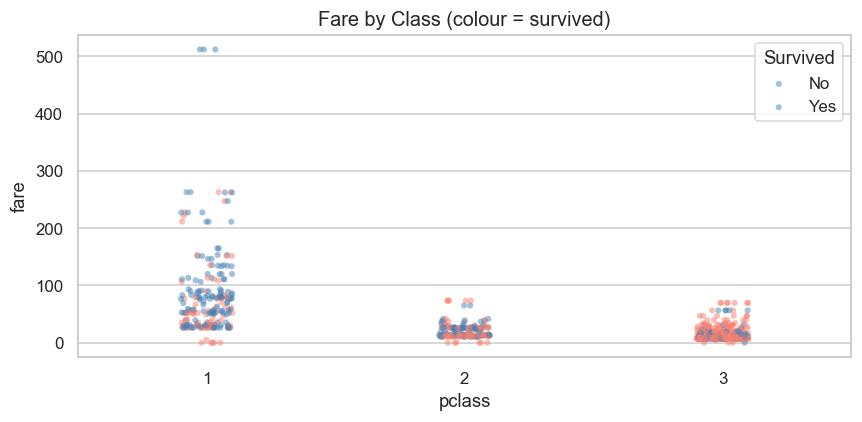

In [25]:
# ── Strip plot (shows every data point) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

sns.stripplot(data=df_clean, x='pclass', y='fare',
              hue='survived', palette={0: 'salmon', 1: 'steelblue'},
              alpha=0.5, jitter=True, size=4, ax=ax)

ax.set_title('Fare by Class (colour = survived)', fontsize=13)
ax.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


### 4.3 — Categorical × Categorical

In [26]:
# ── Cross-tabulation (frequency table) ────────────────────────────────────
ct = pd.crosstab(df_clean['pclass'], df_clean['survived'],
                 margins=True, margins_name='Total')
print("Frequency table — Pclass vs Survived:")
print(ct)


Frequency table — Pclass vs Survived:
survived    0    1  Total
pclass                   
1          80  136    216
2          97   87    184
3         372  119    491
Total     549  342    891


In [27]:
# ── Cross-tab as percentages ──────────────────────────────────────────────
ct_pct = pd.crosstab(df_clean['pclass'], df_clean['survived'],
                     normalize='index') * 100   # normalize='index' = row %
ct_pct.columns = ['Died (%)', 'Survived (%)']
ct_pct = ct_pct.round(1)
print("Row-percentage table:")
print(ct_pct)


Row-percentage table:
        Died (%)  Survived (%)
pclass                        
1           37.0          63.0
2           52.7          47.3
3           75.8          24.2


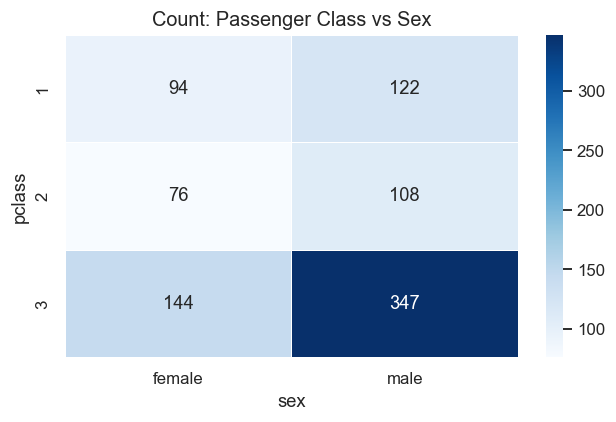

In [28]:
# ── Heatmap of cross-tab ─────────────────────────────────────────────────
ct_heat = pd.crosstab(df_clean['pclass'], df_clean['sex'])

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(ct_heat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Count: Passenger Class vs Sex', fontsize=13)
plt.tight_layout()
plt.show()


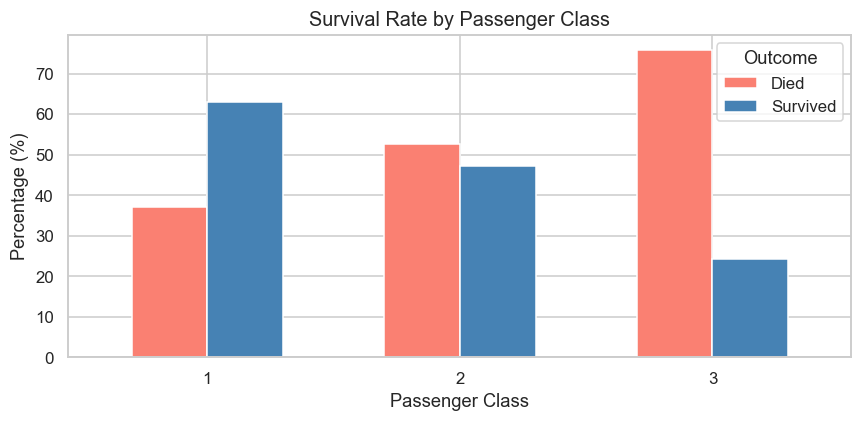

In [29]:
# ── Grouped bar chart (categorical × categorical) ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ct_pct2 = pd.crosstab(df_clean['pclass'], df_clean['survived'],
                      normalize='index') * 100

ct_pct2.plot(kind='bar', ax=ax, color=['salmon', 'steelblue'],
             edgecolor='white', width=0.6)

ax.set_title('Survival Rate by Passenger Class', fontsize=13)
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Percentage (%)')
ax.legend(['Died', 'Survived'], title='Outcome')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


---
## 5 · Multivariate Analysis <a id='5'></a>

Look at **3+ variables simultaneously** to find deeper patterns.


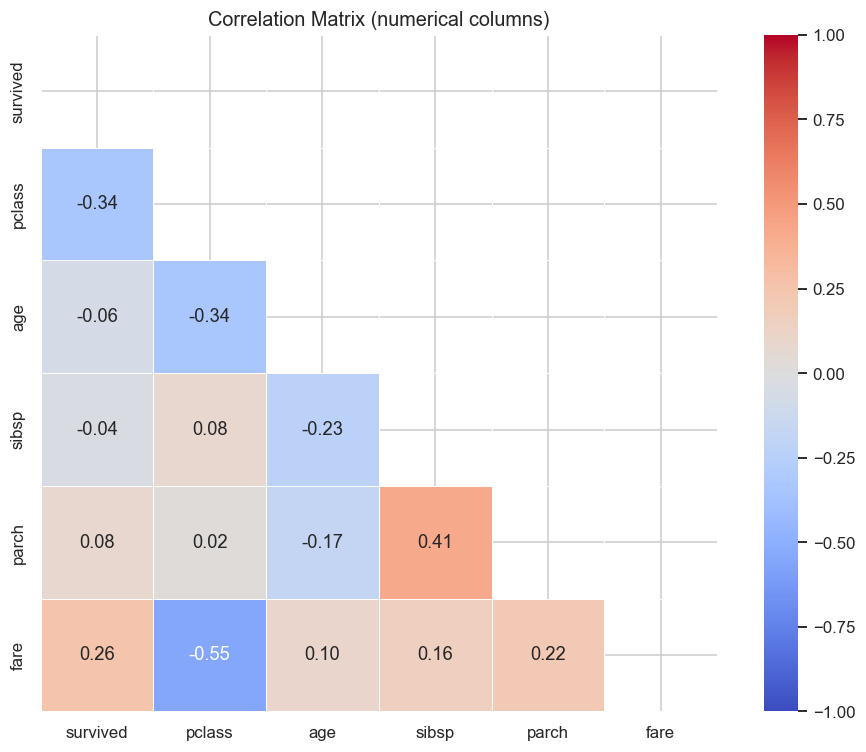

In [30]:
# ── Correlation matrix ────────────────────────────────────────────────────
num_only = df_clean.select_dtypes(include='number')
corr = num_only.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only lower triangle

sns.heatmap(
    corr,
    mask=mask,                # hide upper triangle (it's a mirror)
    annot=True,               # show correlation values in cells
    fmt='.2f',
    cmap='coolwarm',          # blue=negative, red=positive
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title('Correlation Matrix (numerical columns)', fontsize=13)
plt.tight_layout()
plt.show()
# ► Tip: |r| > 0.7 = strong, 0.4–0.7 = moderate, < 0.4 = weak


In [31]:
# ── Find the strongest correlations (top pairs) ──────────────────────────
corr_pairs = (corr.where(mask == False)   # keep lower triangle only
                  .stack()
                  .reset_index()
                  .rename(columns={'level_0': 'col_A', 'level_1': 'col_B', 0: 'r'}))

corr_pairs['abs_r'] = corr_pairs['r'].abs()
top_corr = corr_pairs.sort_values('abs_r', ascending=False).head(10)

print("Top 10 correlated pairs:")
print(top_corr[['col_A', 'col_B', 'r']].to_string(index=False))


Top 10 correlated pairs:
 col_A    col_B         r
  fare   pclass -0.549500
 parch    sibsp  0.414838
   age   pclass -0.339898
pclass survived -0.338481
  fare survived  0.257307
 sibsp      age -0.233296
  fare    parch  0.216225
 parch      age -0.172482
  fare    sibsp  0.159651
  fare      age  0.096688


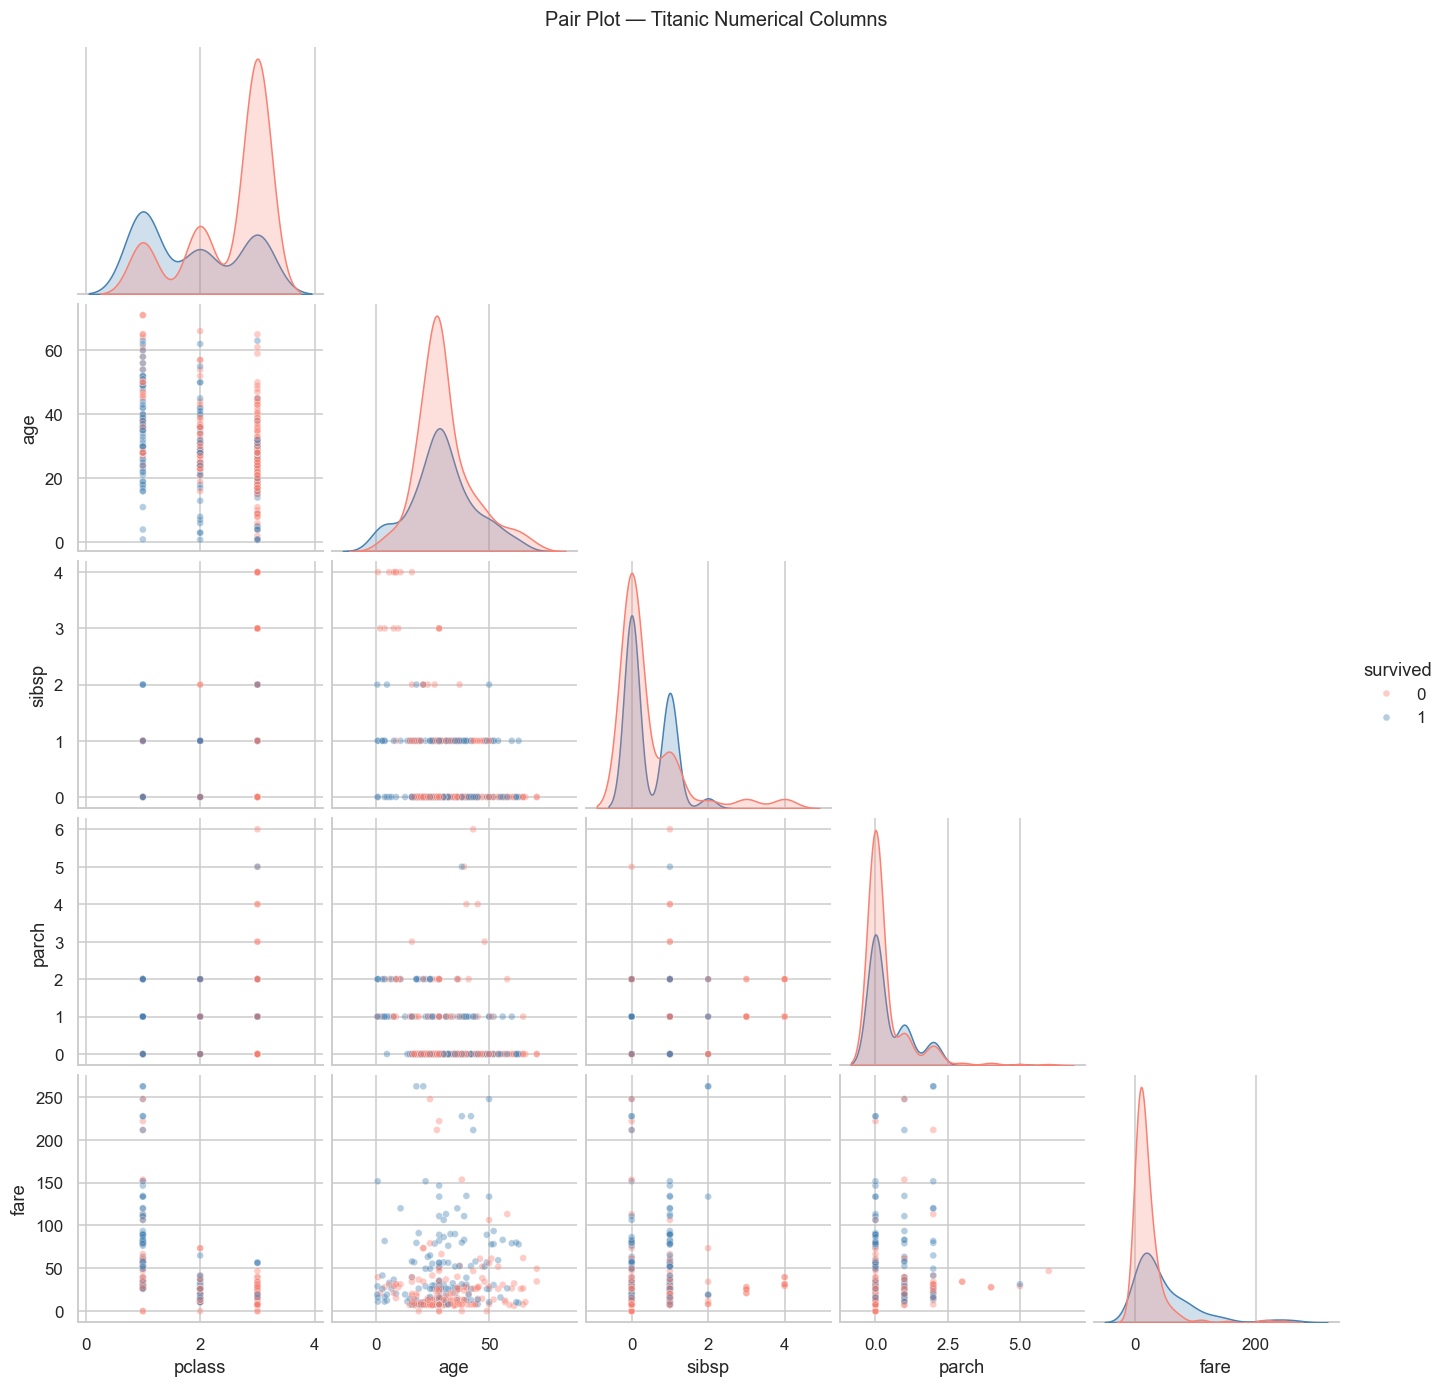

In [34]:
# Remove duplicate columns
sample_pp_clean = sample_pp_clean.loc[:, ~sample_pp_clean.columns.duplicated()]

# Pairplot
g = sns.pairplot(
    sample_pp_clean,
    hue="survived",
    palette={0: "salmon", 1: "steelblue"},
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 20},
    corner=True,
)

g.fig.suptitle("Pair Plot — Titanic Numerical Columns", y=1.01, fontsize=13)

plt.show()

In [35]:
# ── Grouped statistics table ──────────────────────────────────────────────
# Mean of numerical columns, grouped by a categorical variable
group_stats = df_clean.groupby('pclass')[num_cols].mean().round(2)
print("Mean values by Passenger Class:")
group_stats


Mean values by Passenger Class:


,survived,pclass,age,sibsp,parch,fare
pclass,,,,,,
1,0.63,1.0,36.81,0.42,0.36,84.15
2,0.47,2.0,29.77,0.40,0.38,20.66
3,0.24,3.0,25.93,0.62,0.39,13.68


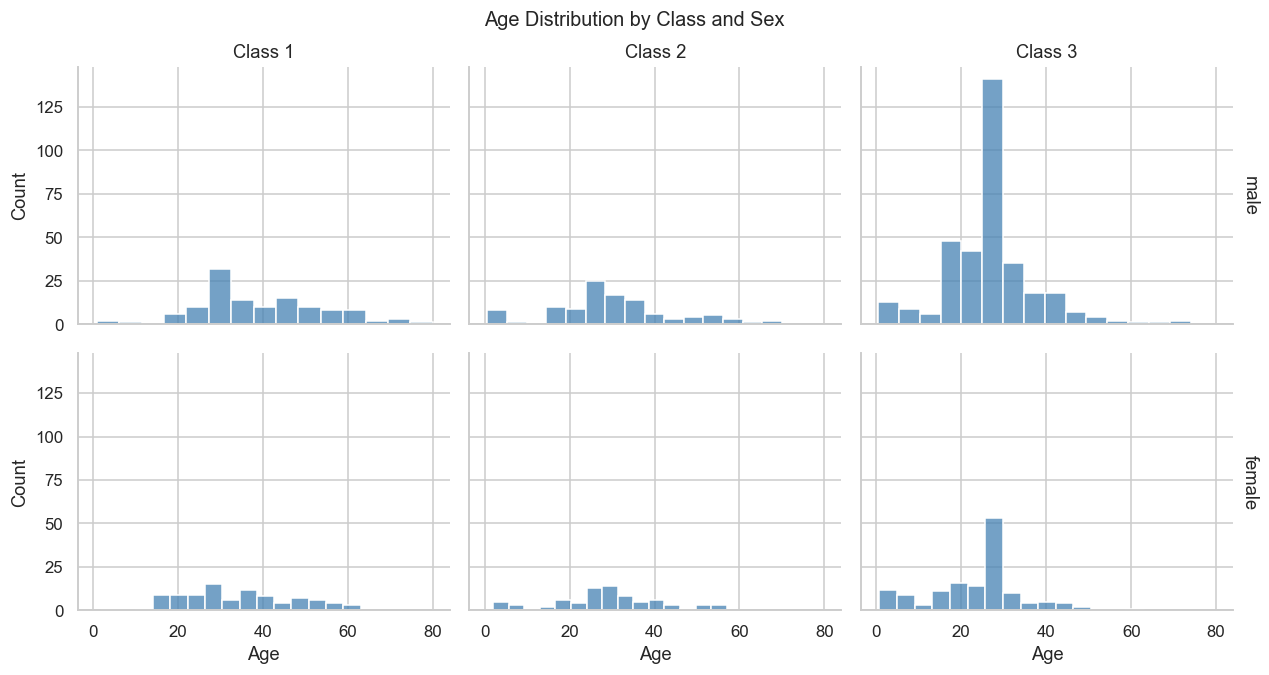

In [36]:
# ── FacetGrid: distribution per category ─────────────────────────────────
g = sns.FacetGrid(df_clean, col='pclass', row='sex',
                  height=3, aspect=1.3, margin_titles=True)
g.map(sns.histplot, 'age', bins=15, color='steelblue')
g.set_axis_labels('Age', 'Count')
g.set_titles(col_template='Class {col_name}', row_template='{row_name}')
g.fig.suptitle('Age Distribution by Class and Sex', y=1.02, fontsize=13)
plt.show()


---
## 6 · Outlier Detection <a id='6'></a>

Outliers can skew models, distort statistics, or represent genuine rare events.
Always **investigate** before removing — sometimes they're the most interesting data.

| Method | When to use |
|--------|------------|
| IQR (Tukey fence) | Robust, works for skewed data |
| Z-score | Assumes normal distribution |
| Visual box plot | Quick first check |


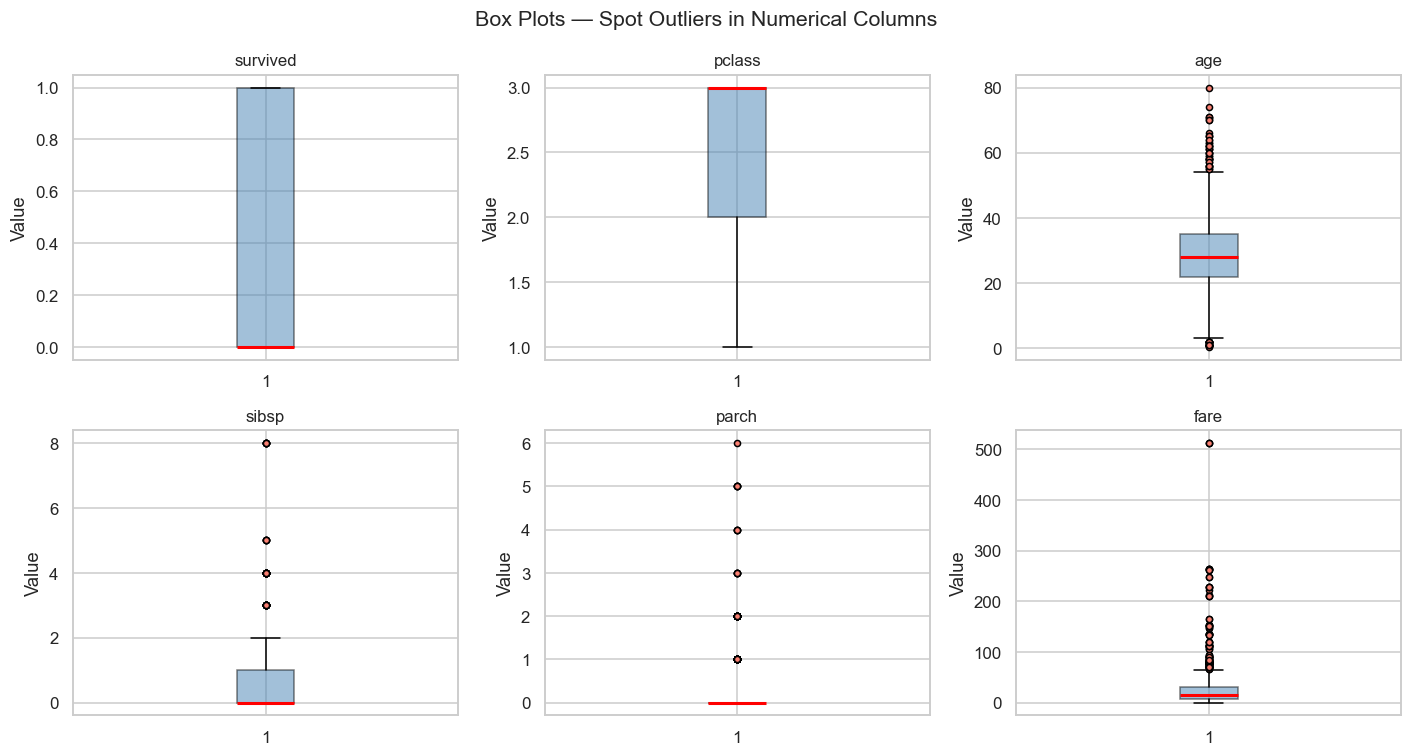

In [37]:
# ── Box plots for all numerical columns ──────────────────────────────────
n_cols_grid = 3
n_rows_grid = -(-len(num_cols) // n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(13, n_rows_grid * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='salmon',
                                    markerfacecolor='salmon', markersize=4))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Box Plots — Spot Outliers in Numerical Columns', fontsize=14)
plt.tight_layout()
plt.show()
# ► Tip: diamonds (♦) beyond the whiskers = potential outliers


In [38]:
# ── IQR method: count and flag outliers ──────────────────────────────────
def iqr_outlier_report(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR      # Tukey lower fence
    upper = Q3 + 1.5 * IQR      # Tukey upper fence
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return {
        'column'   : col,
        'Q1'       : round(Q1, 2),
        'Q3'       : round(Q3, 2),
        'IQR'      : round(IQR, 2),
        'lower_fence': round(lower, 2),
        'upper_fence': round(upper, 2),
        'n_outliers' : len(outliers),
        'outlier_%'  : round(len(outliers) / len(df) * 100, 2)
    }

outlier_report = pd.DataFrame([iqr_outlier_report(df_clean, c) for c in num_cols])
print("IQR Outlier Report:")
outlier_report


IQR Outlier Report:


,column,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,outlier_%
0,survived,0.00,1.0,1.00,-1.50,2.50,0,0.00
1,pclass,2.00,3.0,1.00,0.50,4.50,0,0.00
2,age,22.00,35.0,13.00,2.50,54.50,66,7.41
3,sibsp,0.00,1.0,1.00,-1.50,2.50,46,5.16
4,parch,0.00,0.0,0.00,0.00,0.00,213,23.91
5,fare,7.91,31.0,23.09,-26.72,65.63,116,13.02


In [39]:
# ── Z-score method ────────────────────────────────────────────────────────
# Flags values more than 3 standard deviations from the mean
from scipy.stats import zscore

z_scores    = df_clean[num_cols].apply(zscore)
zscore_mask = (z_scores.abs() > 3)   # True where |z| > 3

print("Rows flagged as outliers by Z-score (|z| > 3):")
print(zscore_mask.sum().rename('n_outliers').to_frame())


Rows flagged as outliers by Z-score (|z| > 3):
          n_outliers
survived           0
pclass             0
age                7
sibsp             30
parch             15
fare              20


In [40]:
# ── Handle outliers: three options ───────────────────────────────────────
col = 'fare'   # ← change to any column

Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
IQR    = Q3 - Q1
lower  = Q1 - 1.5 * IQR
upper  = Q3 + 1.5 * IQR

# Option 1: Remove rows with outliers
df_no_outliers = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
print(f"Option 1 — Rows after removing outliers in '{col}': {len(df_no_outliers)}")

# Option 2: Winsorize (cap values at the fence)
df_winsorized          = df_clean.copy()
df_winsorized[col]     = df_winsorized[col].clip(lower=lower, upper=upper)
print(f"Option 2 — Winsorized max value: {df_winsorized[col].max():.2f} (was {df_clean[col].max():.2f})")

# Option 3: Log transform (reduces impact of large values)
df_log         = df_clean.copy()
df_log[col]    = np.log1p(df_log[col])   # log1p = log(1+x), safe for 0 values
print(f"Option 3 — Log-transformed mean: {df_log[col].mean():.3f}")


Option 1 — Rows after removing outliers in 'fare': 775
Option 2 — Winsorized max value: 65.63 (was 512.33)
Option 3 — Log-transformed mean: 2.962


---
## 7 · Feature Engineering Hints <a id='7'></a>

EDA often reveals opportunities to create better features for modelling.


In [41]:
# ── Create new columns from existing ones ─────────────────────────────────
df_feat = df_clean.copy()

# 1. Family size (combine two columns)
df_feat['family_size'] = df_feat['sibsp'] + df_feat['parch'] + 1  # +1 for the passenger
df_feat['is_alone']    = (df_feat['family_size'] == 1).astype(int)

# 2. Bin a continuous variable into categories
df_feat['age_group'] = pd.cut(
    df_feat['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
)

# 3. Extract from a string column
# df_feat['title'] = df_feat['name'].str.extract(r',\s*(\w+)\.')

# 4. Boolean to integer (for modelling)
if 'adult_male' in df_feat.columns:
    df_feat['adult_male'] = df_feat['adult_male'].astype(int)

# Preview
df_feat[['family_size', 'is_alone', 'age_group']].head(8)


,family_size,is_alone,age_group
0,2,0,YoungAdult
1,2,0,Adult
2,1,1,YoungAdult
3,2,0,YoungAdult
4,1,1,YoungAdult
5,1,1,YoungAdult
6,1,1,Adult
7,5,0,Child


In [42]:
# ── Encoding categorical variables (preview) ─────────────────────────────
# One-hot encoding — creates a binary column per category
sex_dummies = pd.get_dummies(df_feat['sex'], prefix='sex', drop_first=True)
print("One-hot encoded 'sex':")
print(sex_dummies.head())

# Ordinal encoding — map categories to ordered integers
class_map = {'First': 1, 'Second': 2, 'Third': 3}
if 'class' in df_feat.columns:
    df_feat['class_num'] = df_feat['class'].map(class_map)
    print("\nOrdinal encoded 'class':")
    print(df_feat[['class', 'class_num']].head())


One-hot encoded 'sex':
   sex_male
0      True
1     False
2     False
3     False
4      True

Ordinal encoded 'class':
   class class_num
0  Third         3
1  First         1
2  Third         3
3  First         1
4  Third         3


---
## 8 · EDA Summary Checklist <a id='8'></a>

Before handing your data to a model, make sure you can answer these questions:


In [43]:
# ── Auto-generate a quick EDA summary ────────────────────────────────────
print("=" * 55)
print("  EDA SUMMARY")
print("=" * 55)
print(f"  Dataset shape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Numerical cols : {len(num_cols)}  → {num_cols}")
print(f"  Categorical cols: {len(cat_cols)}  → {cat_cols}")
print()

missing_remaining = df_clean.isna().sum()
if missing_remaining.sum() == 0:
    print("  ✅ No missing values")
else:
    print("  ⚠️  Remaining missing values:")
    print(f"  {missing_remaining[missing_remaining > 0].to_dict()}")

print()
print("  Outlier summary (IQR method):")
for _, row in outlier_report.iterrows():
    flag = "⚠️ " if row['outlier_%'] > 5 else "✅"
    print(f"  {flag} {row['column']:<15} → {row['n_outliers']:>4} outliers ({row['outlier_%']}%)")

print()
print("  Top correlations:")
for _, row in top_corr.head(5).iterrows():
    print(f"    {row['col_A']} × {row['col_B']}: r = {row['r']:.3f}")

print()
print("  Checklist:")
checklist = [
    "Shape and column types understood",
    "Missing values investigated and handled",
    "Univariate distributions checked for each column",
    "Bivariate relationships explored for key pairs",
    "Correlation matrix reviewed",
    "Outliers detected and decision made (keep/remove/cap)",
    "New features created if needed",
    "Data types correct for modelling (int/float, no object columns)",
]
for item in checklist:
    print(f"    ☐  {item}")


  EDA SUMMARY
  Dataset shape  : 891 rows × 14 columns
  Numerical cols : 6  → ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
  Categorical cols: 8  → ['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

  ⚠️  Remaining missing values:
  {'embark_town': 2}

  Outlier summary (IQR method):
  ✅ survived        →    0 outliers (0.0%)
  ✅ pclass          →    0 outliers (0.0%)
  ⚠️  age             →   66 outliers (7.41%)
  ⚠️  sibsp           →   46 outliers (5.16%)
  ⚠️  parch           →  213 outliers (23.91%)
  ⚠️  fare            →  116 outliers (13.02%)

  Top correlations:
    fare × pclass: r = -0.549
    parch × sibsp: r = 0.415
    age × pclass: r = -0.340
    pclass × survived: r = -0.338
    fare × survived: r = 0.257

  Checklist:
    ☐  Shape and column types understood
    ☐  Missing values investigated and handled
    ☐  Univariate distributions checked for each column
    ☐  Bivariate relationships explored for key pairs
    ☐  Corre

---
## Automated EDA Tools <a id='auto'></a>

These tools generate a **complete EDA report in 1–3 lines of code**.
Use them for a fast first pass, then dig deeper manually using the sections above.

| Tool | Best for | Output |
|------|---------|--------|
| ydata-profiling | Full statistical report | HTML file |
| sweetviz | Target variable analysis & comparison | HTML file |
| dtale | Interactive spreadsheet-style exploration | Browser app |
| pygwalker | Drag-and-drop Tableau-style charts | Inline Jupyter widget |
| skimpy | Compact terminal summary table | Inline output |
| dataprep | Quick EDA + data cleaning pipeline | HTML / inline |


### 🔷 Tool 1 — ydata-profiling
**Best for:** comprehensive automated report with statistics, distributions, correlations, and missing-value analysis in one HTML file.

```bash
pip install ydata-profiling
```


In [44]:
# ── ydata-profiling — full report ────────────────────────────────────────
# Generates a detailed HTML report saved to disk

import pandas as pd
from ydata_profiling import ProfileReport
import seaborn as sns

df = sns.load_dataset('titanic')

# Create the profile report
# title        → shown at the top of the HTML report
# minimal=True → faster, skips some correlation calculations (good for large data)
profile = ProfileReport(
    df,
    title="Titanic EDA Report",
    minimal=False      # set True for large datasets (>100 000 rows)
)

# Save to an HTML file (opens in any browser)
profile.to_file("eda_report_ydata.html")

print("✅ Report saved → eda_report_ydata.html")
print("   Open this file in your browser to explore the full report.")


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 50.00it/s]

✅ Report saved → eda_report_ydata.html
   Open this file in your browser to explore the full report.


In [45]:
# ── ydata-profiling — display inline (Jupyter only) ──────────────────────
# profile.to_notebook_iframe()   # shows the report inside the notebook
# ► Tip: inline display can be slow for large datasets — use to_file() instead
print("Uncomment profile.to_notebook_iframe() to display inline in Jupyter.")


Uncomment profile.to_notebook_iframe() to display inline in Jupyter.


### 🔷 Tool 2 — sweetviz
**Best for:** comparing two datasets (e.g. train vs test split) or analysing a target variable.

```bash
# Create a dedicated conda env to avoid numpy conflicts:
conda create -n sweetviz python=3.10 -y
conda activate sweetviz
pip install sweetviz pandas openpyxl ipykernel
pip uninstall numpy -y
conda install numpy==1.23.4 -y
```


In [46]:
# ── sweetviz — single dataset report ─────────────────────────────────────
import pandas as pd
import sweetviz as sv
import seaborn as sns

df = sns.load_dataset('titanic')

# Analyze the full dataset
# target_feat → the column you want to predict (shown prominently in report)
my_report = sv.analyze(
    df,
    target_feat='survived'    # optional: highlight your target variable
)

# Save to HTML
my_report.show_html("sweetviz_report.html")
print("✅ Report saved → sweetviz_report.html")


                                             |          | [  0%]   00:00 -> (? left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:07 -> (00:00 left)


Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
✅ Report saved → sweetviz_report.html


In [48]:
# ── sweetviz — compare two datasets (train vs test) ──────────────────────
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

# Compare report highlights differences between train and test
compare_report = sv.compare([train, "Train"], [test, "Test"],
                            target_feat='survived')
compare_report.show_html("sweetviz_compare.html")
print("✅ Compare report saved → sweetviz_compare.html")
# ► Tip: use this AFTER splitting to catch data leakage or distribution shift


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:02 -> (00:00 left)


Report sweetviz_compare.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
✅ Compare report saved → sweetviz_compare.html


### 🔷 Tool 3 — dtale
**Best for:** interactive spreadsheet exploration — sort, filter, and build charts by clicking, no code needed.

```bash
pip install dtale
```


In [1]:
# ── dtale — interactive explorer ─────────────────────────────────────────
import pandas as pd
import dtale
import seaborn as sns

df = sns.load_dataset('titanic')

# Launch a D-Tale instance (opens a web app in your browser)
d = dtale.show(df)

# Open the browser automatically
d.open_browser()

# ► What you can do in the browser UI:
#   • Sort and filter columns
#   • Build charts (scatter, bar, line, heatmap, histogram)
#   • View correlation matrices
#   • Export filtered data
#   • See code for any operation you perform

print("✅ D-Tale launched → check your browser")
print("   Call d.kill() when finished to shut it down.")


ModuleNotFoundError: No module named 'dtale'

In [ ]:
# ── dtale — shut down ─────────────────────────────────────────────────────
# d.kill()   # uncomment when done to free the port
print("Uncomment d.kill() when you are done with the D-Tale session.")


### 🔷 Tool 4 — pygwalker
**Best for:** drag-and-drop Tableau-style chart building inside Jupyter — no coding required for the exploration phase.

```bash
pip install pygwalker
```


In [2]:
# ── pygwalker — interactive chart builder ────────────────────────────────
import pandas as pd
import pygwalker as pyg
import seaborn as sns

df = sns.load_dataset('titanic')

# Launch the GraphicWalker UI inline in Jupyter
walker = pyg.walk(df)

# ► How to use the UI:
#   • Drag column names from the left panel onto X / Y / Colour / Size shelves
#   • Change chart type (scatter, bar, line, map, pie) from the top toolbar
#   • Filter rows using the filter panel
#   • Export your chart as an image with the download button

print("✅ PyGWalker loaded — interact with the UI above")


ModuleNotFoundError: No module named 'pygwalker'

### 🔷 Tool 5 — skimpy
**Best for:** a fast, compact summary table printed directly in the terminal or notebook — like `df.describe()` but much richer.

```bash
conda create -n skimpy python=3.10 -y
conda activate skimpy
pip install skimpy pandas openpyxl ipykernel
# On ARM CPUs only:
pip install polars-lts-cpu
```


In [3]:
# ── skimpy — quick dataset summary ───────────────────────────────────────
import pandas as pd
from skimpy import skim
import seaborn as sns

df = sns.load_dataset('titanic')

# skim() prints:
#   • Data type breakdown
#   • For numerical cols: mean, sd, p0/p25/p50/p75/p100, histogram
#   • For categorical cols: unique count, top values
skim(df)

# ► Tip: works identically on any pandas DataFrame — just swap df


ModuleNotFoundError: No module named 'skimpy'

In [4]:
# ── skimpy — on a custom DataFrame ────────────────────────────────────────
import pandas as pd
from skimpy import skim

custom_df = pd.DataFrame({
    'sales'   : [100, 200, 150, 300, 250, 180, 220],
    'region'  : ['North', 'South', 'North', 'East', 'West', 'South', 'East'],
    'returned': [True, False, False, True, False, False, True]
})

skim(custom_df)


ModuleNotFoundError: No module named 'skimpy'

### 🔷 Tool 6 — dataprep
**Best for:** fast EDA report + built-in data cleaning pipeline (detect missing patterns, type mismatches, duplicates).

```bash
conda create -n dataprep python=3.10 -y
conda activate dataprep
pip install dataprep
```


In [6]:
# ── dataprep — EDA report ─────────────────────────────────────────────────
from dataprep.datasets import load_dataset
from dataprep.eda import create_report

# Load a built-in dataset (titanic, adult, wine, etc.)
df = load_dataset("titanic")

# create_report() generates a full interactive HTML report
report = create_report(df)

# Option A: open in browser
report.show_browser()

# Option B: save to HTML file
# report.save("dataprep_report.html")

print("✅ dataprep report launched in browser")


AttributeError: module 'numpy' has no attribute 'bool8'

In [ ]:
# ── dataprep — explore a single column ────────────────────────────────────
from dataprep.eda import plot

# Detailed view of one column: distribution, stats, missing value pattern
plot(df, 'age')


In [ ]:
# ── dataprep — explore relationship between two columns ──────────────────
from dataprep.eda import plot

# Bivariate analysis in one call
plot(df, 'age', 'fare')


---
## 🏁 Quick-Reference: Manual vs Automated EDA

### When to use which approach

| Situation | Recommended approach |
|-----------|---------------------|
| First look at a new dataset | `skimpy.skim()` → then `ydata-profiling` |
| Deep statistical investigation | Manual EDA (Sections 1–7) |
| Need to share a report with a client/team | `ydata-profiling` or `sweetviz` HTML report |
| Exploring visually without writing code | `dtale` or `pygwalker` |
| Comparing train/test distributions | `sweetviz.compare()` |
| Building a repeatable EDA pipeline | Manual Pandas + Seaborn (Sections 1–7) |
| Quick terminal check during development | `skimpy` or `df.describe()` |

### EDA order of operations

```
1. Load data → check shape, dtypes, sample rows        (Section 1)
2. Missing values → quantify, visualise, handle         (Section 2)
3. Univariate → each column distribution                (Section 3)
4. Bivariate → pairwise relationships                   (Section 4)
5. Multivariate → correlation matrix, pair plot         (Section 5)
6. Outliers → detect, decide, handle                    (Section 6)
7. Feature engineering → new columns, encoding          (Section 7)
8. Document findings → use the checklist                (Section 8)
```
